# 🕵️‍♀️ Exploratory Data Analysis (EDA)

The objective of this notebook is to explore relationships between employee characteristics and attrition. Through visualizations and statistical analysis, we identify patterns that may help explain employee turnover and guide feature selection for machine learning.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")  ## loading dataset


## Department Vs Attrition
To understand whether employee attrition differs across departments, we compare the number of employees who stayed and left in each department.

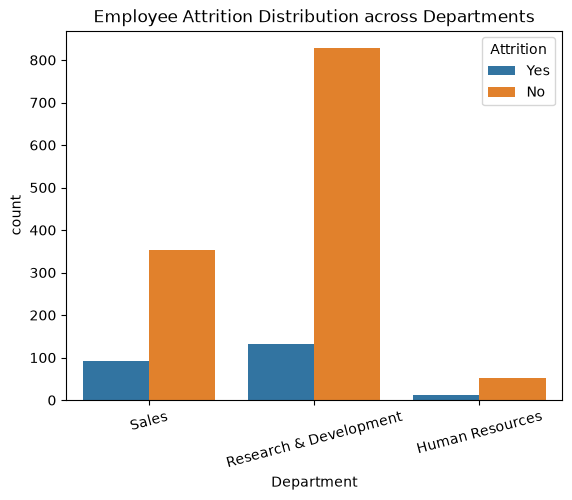

In [19]:
sns.countplot(x= "Department", hue = "Attrition", data = df) ## visualize the distribution of the target variable across departments
plt.title("Employee Attrition Distribution across Departments")
plt.xticks(rotation = 15)
plt.show()

### Analysis

From the chart, the **Research & Development** department has the largest number of employees. It also has the highest number of employees who left the company. However, it also has the highest number of employees who stayed, which is expected because it has the largest workforce.

The **Sales** department has fewer employees than Research & Development but also experiences employee attrition.

The **Human Resources** department has the smallest number of employees and the lowest number of employees leaving the company.

Overall, employee attrition is observed in all departments. Research & Development has the highest number of employees leaving, but this does not necessarily mean it has the highest attrition rate because it also has the largest number of employees.

## Overtime vs Attrition

We analyze whether employees who work overtime are more likely to leave the company compared to those who do not work overtime.

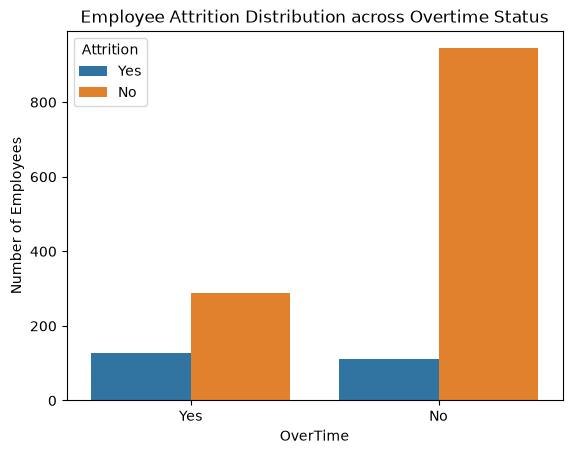

In [20]:
sns.countplot(x= "OverTime", hue = "Attrition", data = df) ## visualize the distribution of the target variable across overtime status)
plt.title("Employee Attrition Distribution across Overtime Status")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()

### Analysis

The graph shows that employees who work overtime have a higher tendency to leave the company compared to those who do not work overtime.

Employees who do not work overtime are more likely to stay, as shown by the significantly larger number of employees in the "No Attrition" category.

This suggests a potential relationship between overtime and employee attrition, which may indicate workload pressure or burnout as contributing factors to employee turnover.

## Monthly Income vs Attrition

We analyze whether employee salary levels influence the likelihood of leaving the company.

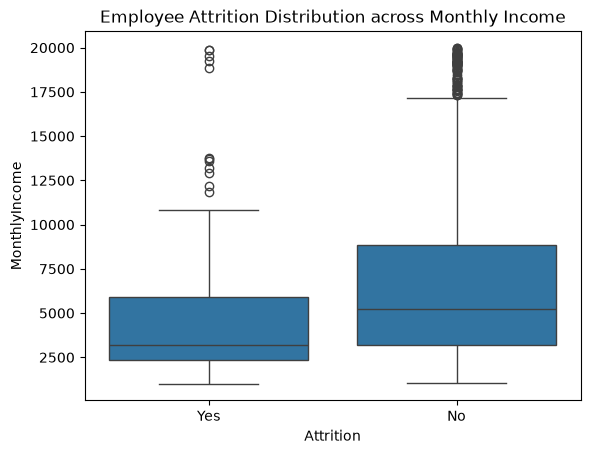

In [21]:
sns.boxplot(x = "Attrition", y = "MonthlyIncome", data = df) ## visualize the distribution of the target variable across monthly income
plt.title("Employee Attrition Distribution across Monthly Income")
plt.show()

### Analysis

The boxplot shows that employees who left the company generally have a lower monthly income than employees who stayed. The median monthly income is higher for employees who remained with the company, suggesting that higher salaries may be associated with improved employee retention.

Employees who stayed also exhibit a wider distribution of monthly income, including many higher-income employees. Although there are high-income employees who left the company, they are relatively few compared to those who stayed.

Overall, the visualization indicates that monthly income may be an important factor in employee attrition and should be considered during feature selection for the machine learning model.

## Age vs Attrition

We analyze whether employee age is associated with employee attrition. This analysis helps determine whether employees of certain age groups are more likely to leave the company.

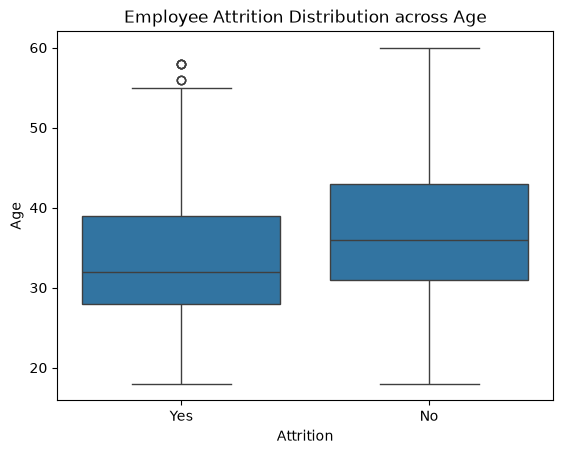

In [22]:
sns.boxplot(x="Attrition", y="Age", data=df)

plt.title("Employee Attrition Distribution across Age")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

### Analysis

The boxplot indicates that employees who left the company generally have a lower median age than employees who remained with the organization. The visualization suggests younger employees in this dataset may be more likely to leave the organization.

Employees who stayed exhibit a slightly wider age distribution, indicating that the company retains employees across a broader range of age groups. Although a few older employees also left the company, they represent a relatively small proportion of the attrition group.

Overall, age appears to be an informative feature for predicting employee attrition and should be retained during feature selection for machine learning model development.

## Job Satisfaction vs Attrition

We analyze whether employees with different levels of job satisfaction have different employee attrition rates.

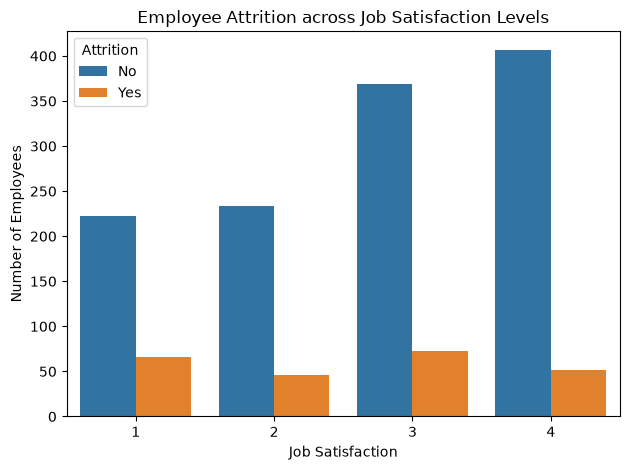

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [23]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)

plt.title("Employee Attrition across Job Satisfaction Levels")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")

plt.tight_layout() ## Adjust the layout to prevent cutting off labels and titles
plt.show()
pd.crosstab(df["JobSatisfaction"], df["Attrition"])


In [27]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
).round(3) * 100   ##  percentage of employees with attrition across different job satisfaction levels

Attrition,No,Yes
JobSatisfaction,,
1,77.2,22.8
2,83.6,16.4
3,83.5,16.5
4,88.7,11.3


### Analysis

The visualization and frequency table indicate a relationship between job satisfaction and employee attrition.

Employees with the lowest job satisfaction (Level 1) have the highest attrition rate, with approximately **22.8%** leaving the company. In contrast, employees with very high job satisfaction (Level 4) have the lowest attrition rate at approximately **11.3%**.

Although employees at satisfaction levels 2 and 3 also experience attrition, their attrition rates are considerably lower than those at the lowest satisfaction level.

These findings suggest that employees who are less satisfied with their jobs are more likely to leave the organization. However, this analysis identifies an association and does not establish a causal relationship.

Job satisfaction appears to be an important predictor of employee attrition. Since employees with lower job satisfaction exhibit higher attrition rates, this feature is likely to provide useful information during model training and should be retained for machine learning.

## Work-Life Balance vs Attrition

We investigate whether employees with poorer work-life balance are more likely to leave the company.

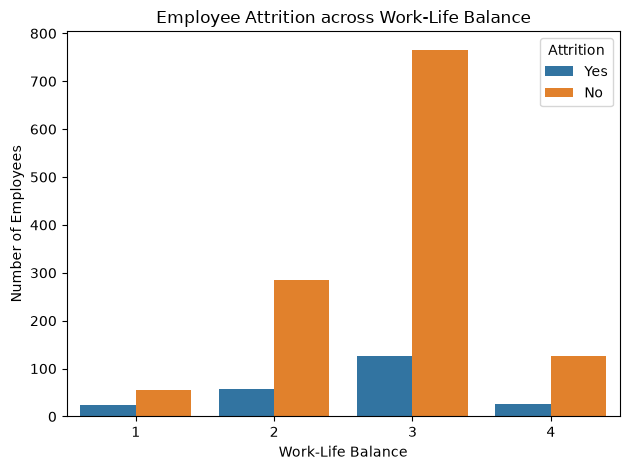

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


In [25]:
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df)

plt.title("Employee Attrition across Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

pd.crosstab(df["WorkLifeBalance"], df["Attrition"])



In [26]:
pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
).round(3) * 100

Attrition,No,Yes
WorkLifeBalance,,
1,68.8,31.2
2,83.1,16.9
3,85.8,14.2
4,82.4,17.6


### Analysis

The analysis indicates a relationship between work-life balance and employee attrition.

Employees reporting the poorest work-life balance (Level 1) have the highest attrition rate at **31.2%**, meaning nearly one in three employees in this group left the company. This is considerably higher than the attrition rates observed for employees with better work-life balance.

Employees with a work-life balance rating of **3 ("Better")** have the lowest attrition rate (**14.2%**), suggesting they are the most likely to remain with the company.

Interestingly, employees reporting the highest work-life balance (Level 4) have a slightly higher attrition rate (**17.6%**) than those at Level 3. This indicates that while work-life balance appears to influence employee retention, it is unlikely to be the only factor contributing to employee turnover.

Overall, the results suggest that poorer work-life balance is associated with a higher likelihood of employee attrition, although additional factors should also be considered.

Work-life balance appears to be an informative predictor of employee attrition. Since employees with poorer work-life balance experience higher attrition rates, this feature should be retained during feature selection. The machine learning model can learn this relationship alongside other employee characteristics to improve the prediction of employee turnover.

## Job Role vs Attrition

We analyze employee attrition across different job roles to identify positions that experience higher turnover.

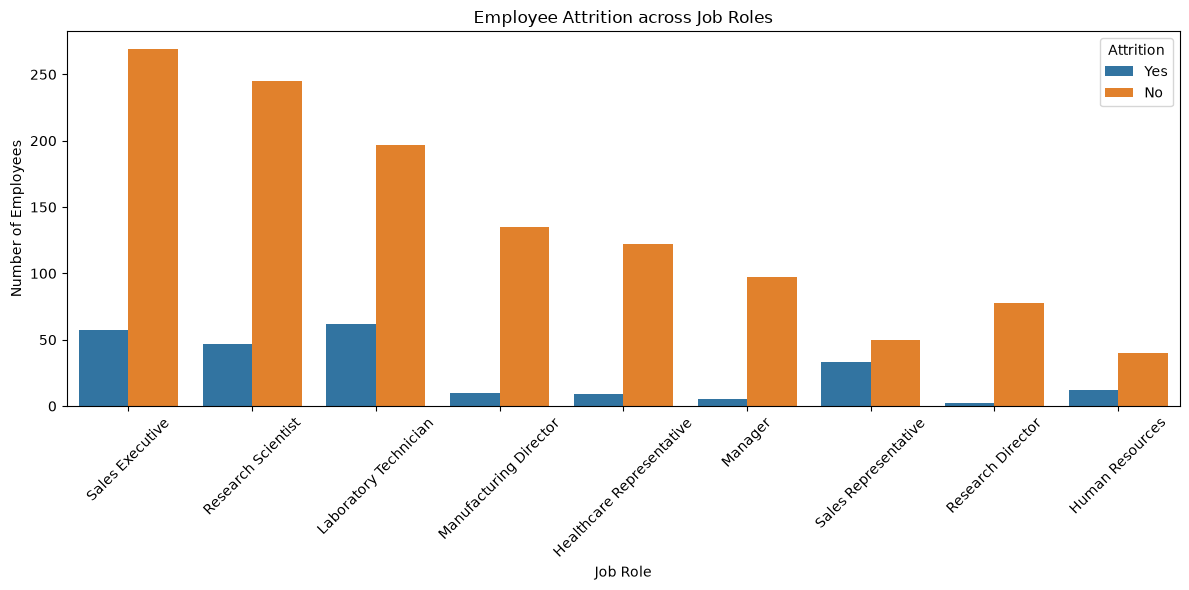

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [28]:
plt.figure(figsize=(12,6))

sns.countplot(x="JobRole", hue="Attrition", data=df)

plt.title("Employee Attrition across Job Roles")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

pd.crosstab(df["JobRole"], df["Attrition"])



In [29]:
pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
).round(3) * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.1,6.9
Human Resources,76.9,23.1
Laboratory Technician,76.1,23.9
Manager,95.1,4.9
Manufacturing Director,93.1,6.9
Research Director,97.5,2.5
Research Scientist,83.9,16.1
Sales Executive,82.5,17.5
Sales Representative,60.2,39.8


### Analysis

The analysis shows that employee attrition varies across different job roles.

Among all job roles, **Sales Representatives** have the highest attrition rate, with **39.8%** of employees leaving the company. This indicates that nearly two out of every five employees in this role left the organization. **Laboratory Technicians** (23.9%) and **Human Resources** employees (23.1%) also experience relatively high attrition rates.

In contrast, **Research Directors** have the lowest attrition rate at **2.5%**, followed by **Managers** (4.9%), **Healthcare Representatives** (6.9%), and **Manufacturing Directors** (6.9%). These roles appear to have much stronger employee retention.

These findings suggest that employee turnover differs across job roles, possibly due to differences in job responsibilities, workload, career progression, compensation, or work environment. However, this analysis identifies an association and does not establish the underlying causes of employee attrition.

Job role appears to be a valuable predictor of employee attrition because some job roles experience substantially higher turnover than others. Including this feature may improve the model's ability to identify employees who are at greater risk of leaving the company.

## Years at Company vs Attrition

We examine whether employee tenure is associated with employee attrition.

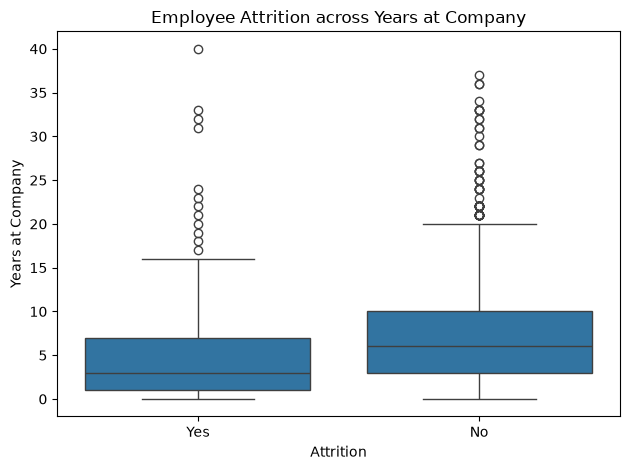

YearsAtCompany,0,1,2,3,4,5,6,7,8,9,...,27,29,30,31,32,33,34,36,37,40
Attrition,,,,,,,,,,,,,,,,,,,,,
No,28,112,100,108,91,175,67,79,71,74,...,2,2,1,2,2,4,1,2,1,0
Yes,16,59,27,20,19,21,9,11,9,8,...,0,0,0,1,1,1,0,0,0,1


In [36]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)

plt.title("Employee Attrition across Years at Company")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.tight_layout()
plt.show()

pd.crosstab(df["Attrition"], df["YearsAtCompany"])

In [37]:
pd.crosstab(
    df["Attrition"],
    df["YearsAtCompany"],
    normalize="index"
).round(3) * 100

YearsAtCompany,0,1,2,3,4,5,6,7,8,9,...,27,29,30,31,32,33,34,36,37,40
Attrition,,,,,,,,,,,,,,,,,,,,,
No,2.3,9.1,8.1,8.8,7.4,14.2,5.4,6.4,5.8,6.0,...,0.2,0.2,0.1,0.2,0.2,0.3,0.1,0.2,0.1,0.0
Yes,6.8,24.9,11.4,8.4,8.0,8.9,3.8,4.6,3.8,3.4,...,0.0,0.0,0.0,0.4,0.4,0.4,0.0,0.0,0.0,0.4


### Analysis

The analysis indicates that employee attrition is highest among employees who have recently joined the company.

Employees with **0 years** at the company have an attrition rate of **36.4%**, while those with **1 year** have an attrition rate of **34.5%**. These are the highest attrition rates among employee groups with substantial numbers of employees.

As employee tenure increases, the attrition rate generally decreases. Employees with **5 to 10 years** at the company typically have attrition rates between **9% and 15%**, suggesting that longer-serving employees are more likely to remain with the organization.

Although some higher tenure groups (such as 23, 31, 32, and 40 years) show unusually high attrition rates, these groups contain very few employees. Therefore, these percentages are not reliable indicators of overall employee turnover and should be interpreted with caution.

Overall, the results suggest that newer employees are more likely to leave the company than employees with longer tenure.

Years at Company appears to be an informative feature for predicting employee attrition. Since employees with shorter tenure exhibit higher attrition rates, the machine learning model can use employee tenure as an important predictor when estimating the likelihood of employee turnover.

## Correlation Heatmap

We examine correlations among numerical variables to understand relationships within the dataset.

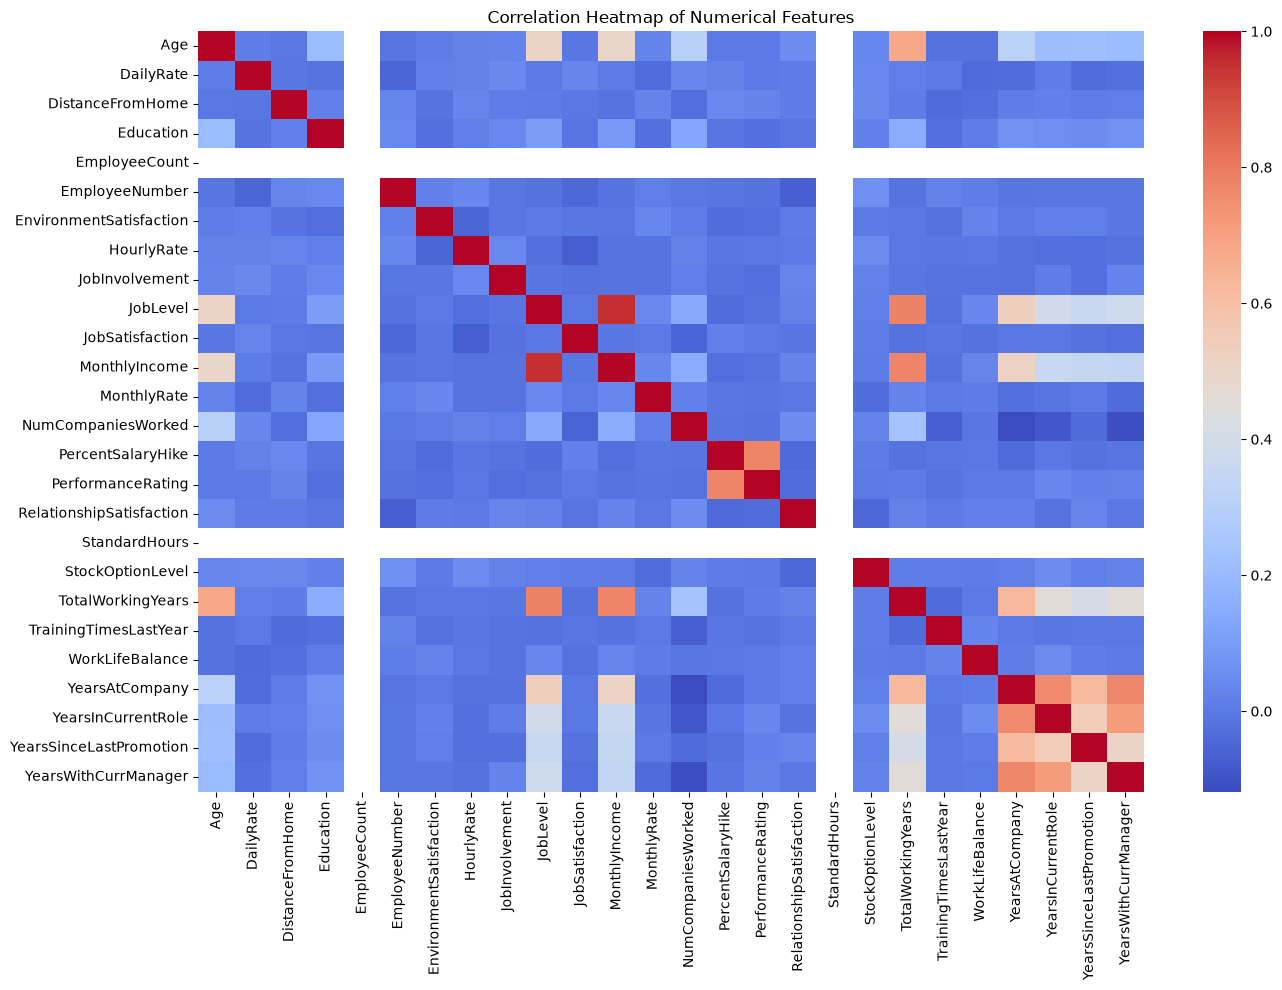

In [12]:
plt.figure(figsize=(14,10))

sns.heatmap(df.select_dtypes(include="number").corr(),
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [38]:
corr_matrix = df.select_dtypes(include="number").corr()  ## shows and calculate the actual correlation values between numerical features

corr_matrix

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


In [39]:
corr = df.select_dtypes(include="number").corr()

corr_pairs = (
    corr.where(~np.tril(np.ones(corr.shape)).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

corr_pairs

JobLevel              MonthlyIncome              0.950300
                      TotalWorkingYears          0.782208
PercentSalaryHike     PerformanceRating          0.773550
MonthlyIncome         TotalWorkingYears          0.772893
YearsAtCompany        YearsWithCurrManager       0.769212
                                                   ...   
YearsWithCurrManager  WorkLifeBalance                 NaN
                      YearsAtCompany                  NaN
                      YearsInCurrentRole              NaN
                      YearsSinceLastPromotion         NaN
                      YearsWithCurrManager            NaN
Length: 676, dtype: float64

### Analysis

The correlation heatmap illustrates the relationships among the numerical variables in the dataset.

Several strong positive correlations are observed. The strongest relationship exists between **JobLevel** and **MonthlyIncome** (0.95), indicating that employees in higher job levels generally earn higher salaries. Similarly, **TotalWorkingYears** is strongly correlated with both **JobLevel** (0.78) and **MonthlyIncome** (0.77), suggesting that employees with more work experience tend to occupy higher positions and receive higher compensation.

Employee tenure variables also exhibit strong positive correlations. **YearsAtCompany** is highly correlated with **YearsWithCurrManager** (0.77) and **YearsInCurrentRole** (0.76), indicating that employees who remain with the organization for longer periods also tend to stay longer in the same role and under the same manager.

Most remaining numerical variables display weak correlations, suggesting that they provide distinct information rather than representing the same underlying characteristics.

The columns **EmployeeCount** and **StandardHours** contain constant values for all employees, resulting in undefined (NaN) correlations. These variables do not provide useful predictive information and can be removed during data preprocessing.

The correlation analysis helps identify relationships between numerical features before model development. Highly correlated variables, such as JobLevel and MonthlyIncome, may provide overlapping information, while weakly correlated variables contribute unique information to the model. Understanding these relationships supports feature selection, helps identify redundant variables, and improves model interpretability.